In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
df=pd.read_csv('orders_dataset.csv')
df

,OrderID,CustomerID,OrderDate,Region,Sales
0,1,C004,2023-01-01,North,141.0
1,2,C005,2023-01-02,North,676.0
2,3,C003,2023-01-03,West,464.0
3,4,C005,2023-01-04,South,797.0
4,5,C005,2023-01-05,South,-9.0
5,6,C002,2023-01-06,South,NaN
6,7,C003,2023-01-07,South,408.0
7,8,C003,2023-01-08,North,675.0
8,9,C003,2023-01-09,West,-66.0
9,10,C005,2023-01-10,West,NaN


In [28]:
df.duplicated().any()

np.False_

In [29]:
df.isnull().sum()

OrderID       0
CustomerID    0
OrderDate     0
Region        0
Sales         5
dtype: int64

In [30]:
df.head(5)

,OrderID,CustomerID,OrderDate,Region,Sales
0,1,C004,2023-01-01,North,141.0
1,2,C005,2023-01-02,North,676.0
2,3,C003,2023-01-03,West,464.0
3,4,C005,2023-01-04,South,797.0
4,5,C005,2023-01-05,South,-9.0


In [31]:
df.shape

(30, 5)

In [32]:
df.columns.to_list()

['OrderID', 'CustomerID', 'OrderDate', 'Region', 'Sales']

In [33]:
# removing negative values
df=df[df['Sales']>=0]
df

,OrderID,CustomerID,OrderDate,Region,Sales
0,1,C004,2023-01-01,North,141.0
1,2,C005,2023-01-02,North,676.0
2,3,C003,2023-01-03,West,464.0
3,4,C005,2023-01-04,South,797.0
6,7,C003,2023-01-07,South,408.0
7,8,C003,2023-01-08,North,675.0
10,11,C004,2023-01-11,North,925.0
11,12,C003,2023-01-12,West,921.0
12,13,C006,2023-01-13,North,465.0
14,15,C002,2023-01-15,North,301.0


In [34]:
# unique customers
df['CustomerID'].nunique()

6

In [35]:
# which regions are present inthe data
df['Region'].unique()

array(['North', 'West', 'South', 'East'], dtype=object)

In [36]:
# fill missing sales with median
df['Sales'].fillna(df['Sales'].median())

0     141.0
1     676.0
2     464.0
3     797.0
6     408.0
7     675.0
10    925.0
11    921.0
12    465.0
14    301.0
15    629.0
16     61.0
17    101.0
19    169.0
21    355.0
22    916.0
23    195.0
24    619.0
25    237.0
26    778.0
27    976.0
28    691.0
29    116.0
Name: Sales, dtype: float64

In [37]:
# remove rows where sales<0
df=df[df['Sales']>=0]
df.shape[0]

23

In [38]:
# convert orderdate to dateetime
df['OrderDate']=pd.to_datetime(df['OrderDate'])
df['OrderDate']
# str(df['OrderDate'].dtype)

0    2023-01-01
1    2023-01-02
2    2023-01-03
3    2023-01-04
6    2023-01-07
7    2023-01-08
10   2023-01-11
11   2023-01-12
12   2023-01-13
14   2023-01-15
15   2023-01-16
16   2023-01-17
17   2023-01-18
19   2023-01-20
21   2023-01-22
22   2023-01-23
23   2023-01-24
24   2023-01-25
25   2023-01-26
26   2023-01-27
27   2023-01-28
28   2023-01-29
29   2023-01-30
Name: OrderDate, dtype: datetime64[ns]

In [39]:
# Total sales per region
df.groupby('Region')['Sales'].sum()

Region
East     2357.0
North    4157.0
South    3364.0
West     1738.0
Name: Sales, dtype: float64

In [40]:
# Avg sales per customer

df.groupby('CustomerID')['Sales'].mean()

CustomerID
C001    674.0
C002    248.0
C003    516.8
C004    593.0
C005    570.0
C006    311.5
Name: Sales, dtype: float64

In [41]:
# top 3 customers by total purchase
df.groupby('CustomerID')['Sales'].sum().nlargest(3)

CustomerID
C004    3558.0
C003    2584.0
C001    2022.0
Name: Sales, dtype: float64

In [42]:
# Region with highest avg sales per order
df.groupby('Region')['Sales'].mean().idxmax()

'South'

In [43]:
# Extract year and month
df['Year']=df['OrderDate'].dt.year
df['Month']=df['OrderDate'].dt.month
df[["OrderDate","Year","Month"]].head()


,OrderDate,Year,Month
0,2023-01-01,2023,1
1,2023-01-02,2023,1
2,2023-01-03,2023,1
3,2023-01-04,2023,1
6,2023-01-07,2023,1


In [49]:
#find monthly total sales and show the trend
df.groupby('Month')['Sales'].sum()
monthly_sales=df.groupby('Month')['Sales'].sum()
monthly_sales

Month
1    11616.0
Name: Sales, dtype: float64

Text(0, 0.5, 'Total Sales')

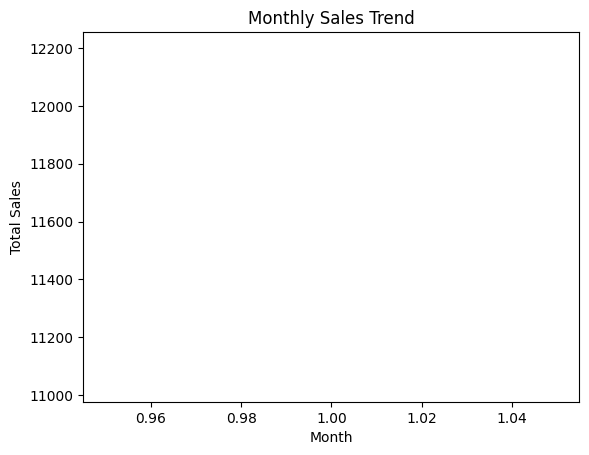

In [52]:
monthly_sales.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

In [53]:
# month with highest sales
monthly_sales.idxmax()

np.int32(1)

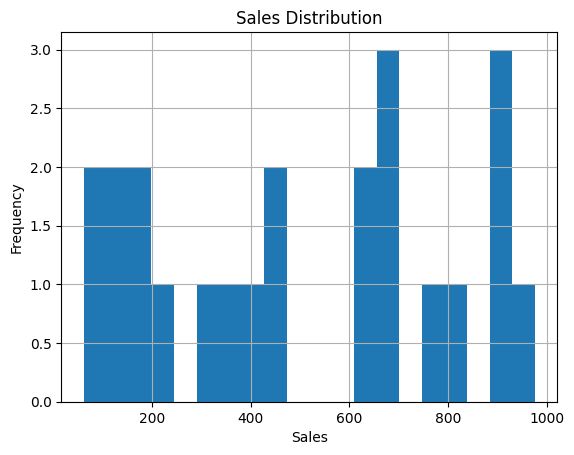

In [55]:
# Histogram of sales
df['Sales'].hist(bins=20)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

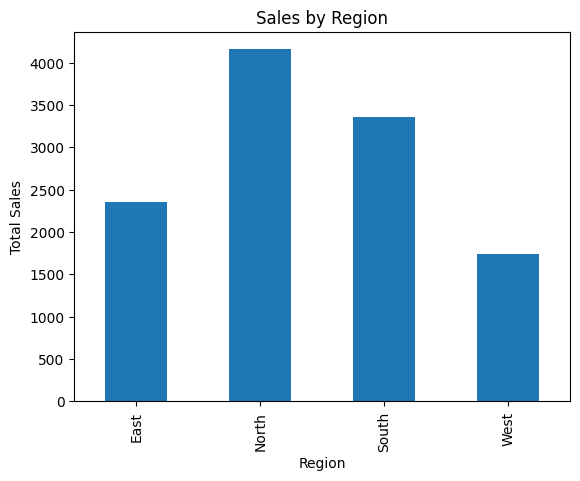

In [57]:
df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

<Axes: xlabel='Month'>

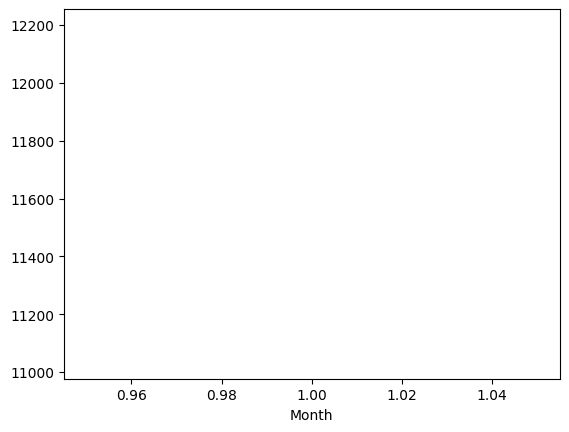

In [59]:
monthly_sales.plot(kind='line')

In [60]:
# Best customer
df.groupby('CustomerID')['Sales'].sum().idxmax()

'C004'

In [ ]:
# moving average of sales with window size 7
df['Sales'].rolling(7).mean()

0            NaN
1            NaN
2            NaN
3            NaN
6            NaN
7            NaN
10    583.714286
11    695.142857
12    665.000000
14    641.714286
15    617.714286
16    568.142857
17    486.142857
19    378.142857
21    297.285714
22    361.714286
23    346.571429
24    345.142857
25    370.285714
26    467.000000
27    582.285714
28    630.285714
29    516.000000
Name: Sales, dtype: float64

In [62]:
#customar retention rate
df.groupby('CustomerID')['Month'].nunique()

CustomerID
C001    1
C002    1
C003    1
C004    1
C005    1
C006    1
Name: Month, dtype: int64

In [63]:
#contribution to revenue
df.sort_values(by='Sales', ascending=False).head(10)

,OrderID,CustomerID,OrderDate,Region,Sales,Year,Month
27,28,C001,2023-01-28,East,976.0,2023,1
10,11,C004,2023-01-11,North,925.0,2023,1
11,12,C003,2023-01-12,West,921.0,2023,1
22,23,C004,2023-01-23,East,916.0,2023,1
3,4,C005,2023-01-04,South,797.0,2023,1
26,27,C004,2023-01-27,South,778.0,2023,1
28,29,C001,2023-01-29,South,691.0,2023,1
1,2,C005,2023-01-02,North,676.0,2023,1
7,8,C003,2023-01-08,North,675.0,2023,1
15,16,C004,2023-01-16,South,629.0,2023,1


In [64]:
#seasonal analysis
df.groupby(['Region','Month'])['Sales'].mean().head(10)

Region  Month
East    1        471.400000
North   1        519.625000
South   1        560.666667
West    1        434.500000
Name: Sales, dtype: float64

In [ ]:
#Detect Outliers
Q1=df['Sales'].quantile(0.25)
Q3=df['Sales'].quantile(0.75)
IQR=Q3-Q1
outliers=df[(df['Sales'] < (Q1 - 1.5 * IQR)) | (df['Sales'] > (Q3 + 1.5 * IQR))]

In [66]:
#Customers ranking over time
df['Rank']=df.groupby('Month')['Sales'].rank(ascending=False)
df['Rank']

0     20.0
1      8.0
2     13.0
3      5.0
6     14.0
7      9.0
10     2.0
11     3.0
12    12.0
14    16.0
15    10.0
16    23.0
17    22.0
19    19.0
21    15.0
22     4.0
23    18.0
24    11.0
25    17.0
26     6.0
27     1.0
28     7.0
29    21.0
Name: Rank, dtype: float64

In [ ]:
np.eye(3)#Identity matrix
# np.zeros((3, 3))#All zeros
# np.ones((3, 3))#All ones

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [ ]:
np.arange(0,10)#step based
np.linspace(1,10,5)#equal spacing

array([ 1.  ,  3.25,  5.5 ,  7.75, 10.  ])

In [97]:
arr=np.array([[1,2,3],[4,5,6],[7,8,9]])
arr[:,0]
arr[::,1]
arr[-1,:]

array([7, 8, 9])

In [ ]:
view=arr.view()
arr[::2,1]=100
view

array([[  1, 100,   3],
       [  4, 100,   6],
       [  7, 100,   9]])

In [98]:
#select even numbwers from an array
arr[arr%2==0]

array([2, 4, 6, 8])

In [107]:
a=np.array([[1,2,3],[4,5,6]])
b=np.array([[10],[20],[30]])
np.dot(a,b)#multhiplication of a*b
# np.matmul(a,b)#matrix multiplication of a*b

array([[140],
       [320]])

In [110]:
arr.ravel()#returns a flattened array
arr.flatten()#returns acopy  of ravel

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [111]:
arr-arr.min()/(arr.max()-arr.min())

array([[0.875, 1.875, 2.875],
       [3.875, 4.875, 5.875],
       [6.875, 7.875, 8.875]])

In [118]:
checkerboard = np.zeros((8,8), dtype=int)
checkerboard[1::2, ::2] = 1
checkerboard[::2, 1::2] = 1
print(checkerboard)

[[0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]]


In [119]:
a = np.array([1,2,3])
b = np.array([4,5,6])

print(np.vstack((a,b)))  # [[1 2 3]
                         #  [4 5 6]]
print(np.hstack((a,b)))  # [1 2 3 4 5 6]

[[1 2 3]
 [4 5 6]]
[1 2 3 4 5 6]


In [123]:
X= np.array([1,2,3])
y = np.array([10,20])
X, y= np.meshgrid(X,y)
print(X)
print(y)

[[1 2 3]
 [1 2 3]]
[[10 10 10]
 [20 20 20]]
